In [ ]:
# Ensure the notebook uses the repository root as its working directory whether launched from notebooks/ or the repository root
import os, sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


# Design Space Exploration by NSGA-II Algorithm

## Imports and Interface

In [14]:
from paradigm.turbo import TurboM_Plus
import numpy as np
import torch
import math
import matplotlib.pyplot as plt
import re, json, os
import subprocess, time
from paradigm.netlist_utils import CircuitParams, FitnessFunction_Prallel_Tailor, make_fitness_function
import csv
import pandas as pd

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

## Function and Module Definitions

In [15]:
def draw_pareto_NSGA2(csv_path, ckt_name, weight_vectors=None, STALE=False):
    '''
    Display the results after breadth-first search. Some original points may have been erased because they were non-STALE; show only non-STALE Pareto points in five colors for numerical comparison
    
    By default, use all weights and add ['NSGA-II']; if weight is None, use every weight
    '''
    
    # Read the CSV file
    # csv_path = f'{database_path}/{ckt_name}/result.csv'
    
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    weight = df["performance weight"]
    
    # Determine which weights to plot
    if weight_vectors is None:
        # Use all weights appearing in df["performance weight"]
        weight_vectors = df["performance weight"].unique()
    else:
        if "['NSGA-II']" not in weight_vectors:
            weight_vectors.append("['NSGA-II']")
    
    if STALE==False:
        # Keep only non-STALE points
        mask = (path != 'STALE')
        GBW = GBW[mask]
        Gain = Gain[mask]
        Pdiss = Pdiss[mask]
    
    # Group by weight
    GBW_list = []
    Gain_list = []
    Pdiss_list = []
    for weight_vector in weight_vectors:
        mask = (weight == weight_vector)
        # # Raise an error if all weights are zero
        # if mask.sum() == 0:
        #     raise ValueError(f'No data found for weight vector: {weight_vector}')
        GBW_list.append(GBW[mask])
        Gain_list.append(Gain[mask])
        Pdiss_list.append(Pdiss[mask])
        
    # Plot each group
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    for i in range(len(weight_vectors)):
        GBW = GBW_list[i]
        Gain = Gain_list[i]
        Pdiss = Pdiss_list[i]
        weight = weight_vectors[i]
        
        color = colors[i % len(colors)]
        
        x = 20 * np.log10(GBW)          # GBW/dB
        y = Gain                        # Gain/dB
        z = 0.1 - Pdiss                 # 0.1 - Pdiss
        
        ax.scatter(x, y, z, c=color,  marker='o', label=weight)
    

    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} NSGA-II Search')
    ax.legend()
    plt.show()
    
# Extract training data from the CSV
def read_para_perf_from_csv(csv_path, contain_stale=True):
    """
    Read parameter solutions and performance metrics for all circuit samples in the CSV; optionally keep only Pareto-optimal data
    
    Returns
        1. 1. Parameter solutions, a NumPy array with shape (n, m), where n is the number of samples and m is the number of parameters
        2. 2. Performance metrics, a NumPy array with shape (n, p), where n is the number of samples and p is the number of metrics (3)
        The metrics are GBW (Hz), Gain (dB), and Pdiss (W)
    """
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # If only Pareto-optimal data are retained
    if not contain_stale:
        # Keep only rows whose `solution path` is VALID
        df = df[df['solution path'] != 'STALE']
    
    # Extract performance metrics
    GBW = df['GBW']    # Hz, float64
    Gain = df['Gain']  # dB, float64
    Pdiss = df['Pdiss']  # W, float64
    
    # Extract parameter solutions and convert them to a NumPy array
    solution_vectors = df['solution vector']
    param_array = np.vstack(solution_vectors.apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')))
    
    # Combine the performance metrics into one array
    perf_array = np.array([GBW, Gain, Pdiss]).T
    
    return param_array, perf_array

def plot_database_csv_withSTALE(csv_path, ckt_name):
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    
    # Group the data
    mask_valid = (path != 'STALE')
    GBW_v, Gain_v, Pdiss_v = GBW[mask_valid], Gain[mask_valid], Pdiss[mask_valid]
    GBW_s, Gain_s, Pdiss_s = GBW[~mask_valid], Gain[~mask_valid], Pdiss[~mask_valid]
    
    # Transform the coordinates
    x_v = 20 * np.log10(GBW_v)          # GBW/dB
    y_v = Gain_v                        # Gain/dB
    z_v = 0.1 - Pdiss_v                 # 0.1 - Pdiss
    
    x_s = 20 * np.log10(GBW_s)
    y_s = Gain_s
    z_s = 0.1 - Pdiss_s
    
    # Plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_v, y_v, z_v, c='blue',  marker='o', label='Valid')
    ax.scatter(x_s, y_s, z_s, c='red',   marker='x', label='Stale')
    
    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} Performance (Valid vs Stale)')
    ax.legend()
    plt.show()

# Optimization problem class
class CircuitProblem(Problem):
    def __init__(self, n_var, n_obj, lb, ub, simulator):
        super().__init__(n_var=n_var, n_obj=n_obj, xl=lb, xu=ub)
        self.simulator = simulator  # Simulator function

    def _evaluate(self, X, out, *args, **kwargs):
        # X is a decision-variable matrix with shape (n_samples, n_var)
        # Call the simulator and return a performance-metric matrix with shape (n_samples, n_obj)
        out["F"] = self.simulator(X)

def simulator_np(X):
    '''
    Input X is a NumPy array with shape (n_samples, n_var)
    
    Output F is a NumPy array with shape (n_samples, n_obj), corresponding to GBW, Gain, and 0.1-Pdiss; all are maximized
    '''
    
    # Convert the NumPy array to a PyTorch tensor
    X_tensor = torch.tensor(X, dtype=torch.float32).squeeze(0)
    
    # Call C2P_Sim for simulation
    F_tensor = C2P_Sim(X_tensor)    # GBW, Gain, Pdiss
    
    # Transform the third column to 0.1 - Pdiss
    F_tensor[:, 2] = 0.1 - F_tensor[:, 2]
    
    # Convert the result to a NumPy array and return it
    return F_tensor.detach().numpy()

def inv_simulator_np(X):
    '''
    Input X is a NumPy array with shape (n_samples, n_var)
    
    Output F is a NumPy array with shape (n_samples, n_obj), corresponding to -GBW, -Gain, and -(0.1-Pdiss); all are minimized
    '''
    
    # Convert the NumPy array to a PyTorch tensor
    X_tensor = torch.tensor(X, dtype=torch.float32).squeeze(0)
    
    # Call C2P_Sim for simulation
    F_tensor = C2P_Sim(X_tensor)    # GBW, Gain, Pdiss
    
    # Transform the third column to 0.1 - Pdiss
    F_tensor[:, 2] = 0.1 - F_tensor[:, 2]
    
    # Convert the result to a NumPy array, negate it, and return it
    return -F_tensor.detach().numpy()


# SMC

**100-100-100-100-20: TuRBO uses 10 points per batch; NSGA-II uses 50 initial points, still 5,000 simulations**

SMC also uses 50 initial points but runs 20 batches, for 1,000 simulations total.

In [16]:
# Interface
# Use CSMC018
technique_path = './circuits/design_space.json'
scs_mdl_path = './circuits'
run_path = './runs'
database_path = './circuit_database'

# Circuit name provided by the user for Benchmark evaluation
# ckt_name = input('\033[32mPlease input the circuit name: [ckt_name]\n')
# SMC/NMCNR/DFCFC1/NGCC/TCFC/AZC/IAC
ckt_name = 'SMC'

# Check if there is a directory of scs and mdl files for the circuit
if not os.path.exists(scs_mdl_path+'/'+ckt_name):
    print(f'\033[31mPlease add netlist and testbench files (in the format of scs and mdl) for the circuit [{ckt_name}] before running the Benchmark\033[0m')
    
scs_mdl_paths = [
    {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.mdl', 'name': 'da'},
    {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.mdl', 'name': 'tran'},
    ]

ckt_database_path = database_path + '/' + ckt_name

In [17]:
# Initialize circuit_database if it has not been initialized
# Directory structure:
# circuit_database - ckt_name - raw
#                             - result.csv
#                             - result_folder - time - ckt_name.scs
#                                                    - ckt_name.measure    
if not os.path.exists(database_path+'/'+ckt_name):
    os.system(f'mkdir {database_path}/{ckt_name}')
    
    # raw/ stores original netlists and test files
    os.system(f'mkdir {database_path}/{ckt_name}/raw')
    os.system(f'cp {scs_mdl_path}/{ckt_name}/* {database_path}/{ckt_name}/raw')
    
    # result.csv stores high-performing metrics and parameter pairs discovered during exploration
    os.system(f'touch {database_path}/{ckt_name}/result.csv')
    # The CSV header is GBW, Gain, Pdiss, time, performance weight, solution vector, solution path
    with open(f'{database_path}/{ckt_name}/result.csv', 'w') as f:
        f.write('GBW, Gain, Pdiss, Fitness, time, performance weight, solution vector, solution path\n')
    
    # result_folder stores complete netlists and simulation results corresponding to the performance metrics
    os.system(f'mkdir {database_path}/{ckt_name}/result_folder')


## Loading Initial Optimization Points

In [18]:
# Read database parameters
csv_path = ckt_database_path + '/' + 'result.csv'
# csv read
ckt_database_csv = pd.read_csv(csv_path)
# Strip whitespace from column names
ckt_database_csv.columns = ckt_database_csv.columns.str.strip()

# info head groupby
print(ckt_database_csv.info())
print("--"*20)

# print(ckt_database_csv.head())
# print("--"*20)

# Print the distribution of performance weight, grouped by value
print(ckt_database_csv['performance weight'].value_counts())

# Print the counts of STALE and non-STALE `solution path` entries
print("STALE Cound: ",ckt_database_csv[ckt_database_csv['solution path'] == 'STALE'].shape[0])
print("VALID Count: ", ckt_database_csv[ckt_database_csv['solution path'] != 'STALE'].shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GBW                 286 non-null    float64
 1   Gain                286 non-null    float64
 2   Pdiss               286 non-null    float64
 3   Fitness             286 non-null    object 
 4   time                286 non-null    object 
 5   performance weight  286 non-null    object 
 6   solution vector     286 non-null    object 
 7   solution path       286 non-null    object 
dtypes: float64(3), object(5)
memory usage: 18.0+ KB
None
----------------------------------------
performance weight
[1, 1, 1]      147
['NSGA-II']     92
[0, -1, 1]      39
[1, 0, -1]       8
Name: count, dtype: int64
STALE Cound:  181
VALID Count:  105


In [19]:
# print(read_para_perf_from_csv(csv_path, contain_stale=True))

initial_samples_all, _ = read_para_perf_from_csv(csv_path, contain_stale=True)
initial_samples_pareto, _ = read_para_perf_from_csv(csv_path, contain_stale=False)

print("All param shape: ", initial_samples_all.shape)
print("Pareto param shape: ", initial_samples_pareto.shape)

All param shape:  (286, 11)
Pareto param shape:  (105, 11)


### Plotting Functions and Initial-Point Visualization

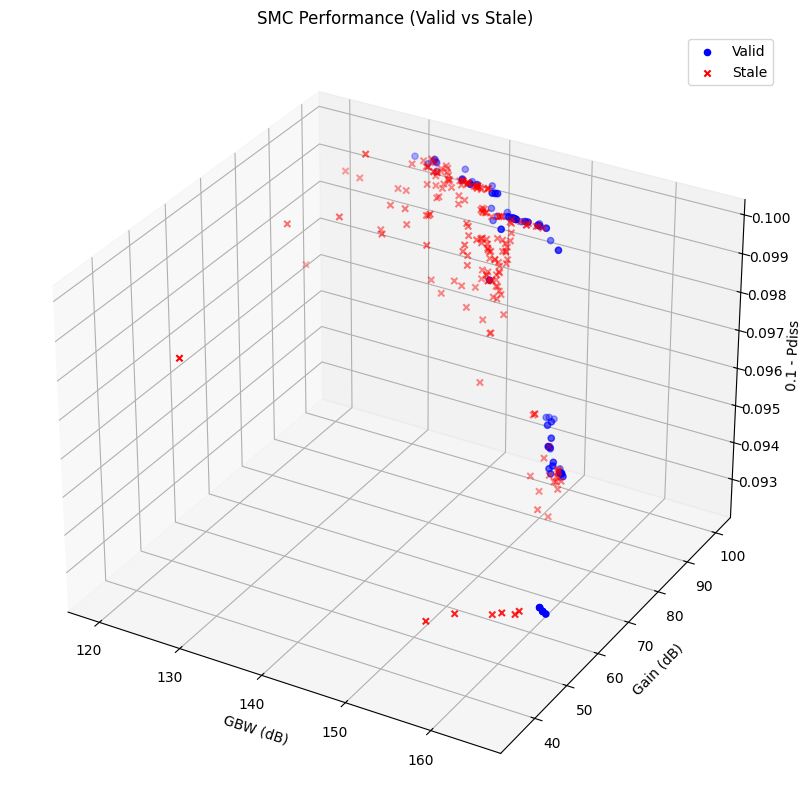

In [20]:
# Call
plot_database_csv_withSTALE(csv_path, ckt_name)

## Configuration and Optimization Problem Definition

In [21]:
# Define the optimization problem

# Parameter configuration
circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)
# Optimization-parameter dimension
var_dim = len(circuit.variables)
# Optimization-parameter bounds
var_lb = np.array(circuit.lb)
var_ub = np.array(circuit.ub)
# Objective dimension
obj_dim = 3 # GBW, Gain, Pdiss（Multi-objective optimization directly uses circuit performance as the objectives）

In [22]:
# Simulator
from paradigm.netlist_utils import C2P_Simulator
circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)
C2P_Sim = C2P_Simulator(scs_mdl_paths, run_path, ckt_name, circuit.params, circuit.wsub, database_path, ["NSGA-II"], Save2Database_flag=True)    # Each simulation result may be saved to the database according to whether it is Pareto-optimal
# C2P_Sim accepts a PyTorch tensor z with shape (n_samples, n_var) and returns performance metrics with shape (n_samples, n_obj)

# # Simple check
# test_X = initial_samples_all[:2, :]
# print("Test X: ", test_X)
# print("Test F: ", inv_simulator_np(test_X))

## Start NSGA-II

Initial samples shape:  (50, 11)
Initial samples size:  50
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |     50 |             - |             -
     2 |      100 |     18 |  0.2176638243 |         ideal
     3 |      150 |     31 |  0.4055367417 |         ideal
     4 |      200 |     33 |  0.0050370574 |         ideal
     5 |      250 |     42 |  0.7373329153 |         ideal
     6 |      300 |     49 |  0.0620652734 |         nadir
     7 |      350 |     47 |  0.0056057445 |         nadir
     8 |      400 |     50 |  0.6469980747 |         nadir
     9 |      450 |     50 |  0.0149224074 |             f


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


    10 |      500 |     50 |  0.0550956890 |         ideal
    11 |      550 |     50 |  0.0178922097 |         nadir
    12 |      600 |     50 |  0.2802778671 |         nadir
    13 |      650 |     50 |  0.5304369182 |         ideal
    14 |      700 |     50 |  0.0145092599 |             f
    15 |      750 |     50 |  0.0102864931 |             f
    16 |      800 |     50 |  0.0028996732 |         ideal


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


    17 |      850 |     50 |  0.0136827874 |             f
    18 |      900 |     50 |  0.0041137658 |         nadir
    19 |      950 |     50 |  0.2850067340 |         ideal
    20 |     1000 |     50 |  0.0961863872 |         ideal


...

    87 |     4350 |     50 |  0.0071454305 |             f
    88 |     4400 |     50 |  0.0645793566 |         nadir


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


    89 |     4450 |     50 |  0.0177291189 |             f
    90 |     4500 |     50 |  0.0081122582 |             f
    91 |     4550 |     50 |  0.0950035061 |         ideal
    92 |     4600 |     50 |  0.0553531748 |         ideal
    93 |     4650 |     50 |  0.0088139509 |         nadir
    94 |     4700 |     50 |  0.0069597735 |         ideal


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


    95 |     4750 |     50 |  0.0104303605 |             f
    96 |     4800 |     50 |  0.0136621160 |         ideal
    97 |     4850 |     50 |  0.0126782620 |             f
    98 |     4900 |     50 |  0.0025238337 |         ideal
    99 |     4950 |     50 |  0.0097765077 |             f
   100 |     5000 |     50 |  0.0051837149 |         ideal
Save nsga2 result to ./circuit_database/SMC/result_20250522-022232_allweights_nsga2.csv


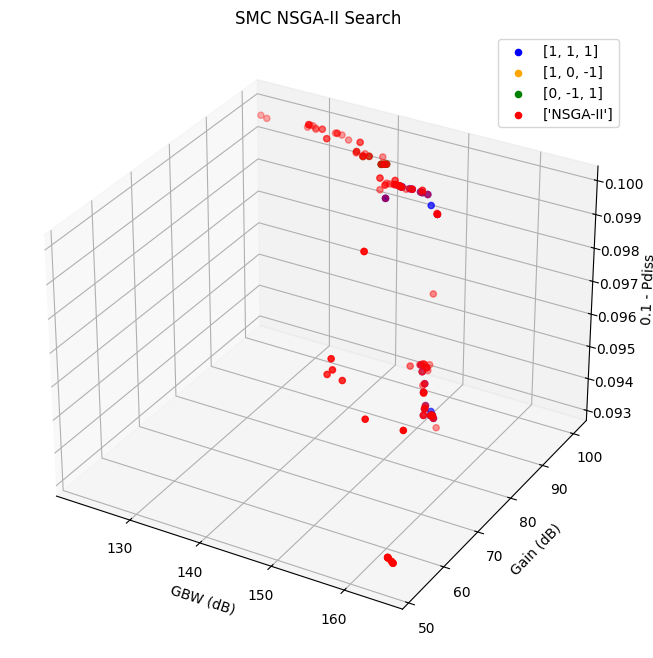

In [23]:
# Define the optimization problem

target_problem = CircuitProblem(
    n_var=var_dim,
    n_obj=obj_dim,
    lb=var_lb,
    ub=var_ub,
    simulator=inv_simulator_np  # Ensure that the problem matches the optimization algorithm: this is a minimize algorithm, so every Simulator output dimension must be minimized
    # NOTE: If the problem and algorithm directions do not match (for example, some Simulator objectives are maximized and others minimized) but minimize is still used
    # the algorithm may fail to converge; pymoo may compute an invalid negative progress percentage and raise an error
    
)

# Configure the NSGA2 algorithm
initial_samples_count = 50
initial_samples = initial_samples_all.copy()

if initial_samples.shape[0] > initial_samples_count:
    # Prefer Pareto-optimal samples
    if initial_samples_pareto.shape[0] > initial_samples_count:
        # If the number of Pareto-optimal samples exceeds the initial population size
        # Sample randomly without replacement
        initial_samples = initial_samples_pareto[np.random.choice(initial_samples_pareto.shape[0], initial_samples_count, replace=False)]
    else:
        # If the number of Pareto-optimal samples is smaller than the initial population size
        # Use the best samples plus the remaining samples drawn randomly without replacement
        initial_samples = np.vstack((initial_samples_pareto, initial_samples_all[np.random.choice(initial_samples_all.shape[0], initial_samples_count - initial_samples_pareto.shape[0], replace=False)]))
else:
    # If there are too few initial points, fill the population with random samples automatically
    to_generate_count = initial_samples_count - initial_samples.shape[0]
    generated_samples = np.random.uniform(low=var_lb, high=var_ub, size=(to_generate_count, var_dim))
    initial_samples = np.vstack((initial_samples, generated_samples))

print("Initial samples shape: ", initial_samples.shape)
print("Initial samples size: ", initial_samples_count)
algorithm = NSGA2(
    pop_size=initial_samples_count,
    sampling=initial_samples  # Set the initial population
)

# Define the stopping condition, such as a fixed number of generations
termination = get_termination("n_gen", 100)

# Run the optimization
res = minimize(
    target_problem,
    algorithm,
    termination,
    seed=1,
    verbose=True
)

# Save another result after optimization
time_stamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
save_file_path = f'{database_path}/{ckt_name}/result_{time_stamp}_allweights_nsga2.csv'
os.system(f'cp {database_path}/{ckt_name}/result.csv {save_file_path}')
print(f'\033[32mSave nsga2 result to {save_file_path}\033[0m')

# Plot
draw_path = f'{database_path}/{ckt_name}/result.csv'
draw_pareto_NSGA2(draw_path,ckt_name)

#### Interpreting NSGA-II Output

This output is the **per-generation iteration log (iteration report)** produced by **pymoo** during multi-objective optimization (such as NSGA-II). It shows the main statistics of the optimization process; each column is explained below.

---

Header

| Field       | Meaning                                             |
| ----------- | --------------------------------------------------- |
| `n_gen`     | Current generation number, starting at 1            |
| `n_eval`    | Cumulative number of objective-function evaluations (simulations) so far |
| `n_nds`     | Number of non-dominated solutions in the current population (Pareto front) |
| `eps`       | Metric for population change: **epsilon progress metric** (ε metric) |
| `indicator` | Indicator used to compute the current `eps` (for example, `ideal`, `nadir`, or `f`) |

---

Column details

 ✅ `n_gen`

* The generation number. For example:

  ```
  n_gen = 4   →  generation 4 of the evolution
  ```

 ✅ `n_eval`

* The total number of function evaluations (for example, simulations) so far.

  * Each sample sent to the simulator for performance evaluation counts as one evaluation.
  * For example:

    ```
    n_eval = 194   →  194 evaluations (simulator calls) have been completed
    ```

 ✅ `n_nds` (number of non-dominated solutions)

* The number of solutions on the **non-dominated front (Pareto front)** in the current generation.
* A larger value means more Pareto-optimal solutions, which may indicate better diversity and quality.

  * For example:

    ```
    n_nds = 50   →  50 mutually non-dominated solutions
    ```

 ✅ `eps` (epsilon indicator)

* The difference (evolution progress) between the current Pareto front and the previous generation's front.
* It is a convergence metric; smaller values indicate that the population is stabilizing (converging).

  * It is often used for automatic termination (convergence is declared when eps falls below a threshold).
  * For example:

    ```
    eps = 0.0031   →  the current and previous fronts are very close, with little change
    ```

 ✅ `indicator`

* The method used to compute `eps`:

| Value   | Meaning                                   |
| ------- | ----------------------------------------- |
| `ideal` | Epsilon comparison relative to the ideal point (the minimum of each objective) |
| `nadir` | Comparison relative to the nadir point (the maximum of each objective) |
| `f`     | Comparison based on the overall distance between objective vectors (generalized front-based eps) |
| `-`     | Not yet computed (for example, in the first generation) |

---

Example row (generation 5)

```
     5 |      244 |     24 |  0.0031398550 |         ideal
```

This means:

* The current generation is 5;
* 244 function evaluations have been completed;
* The current Pareto front contains 24 non-dominated solutions;
* The ideal-point offset from the previous front is 0.0031, indicating convergence;
* `indicator = ideal`: epsilon is measured relative to the ideal point.

---

## Result Comparison

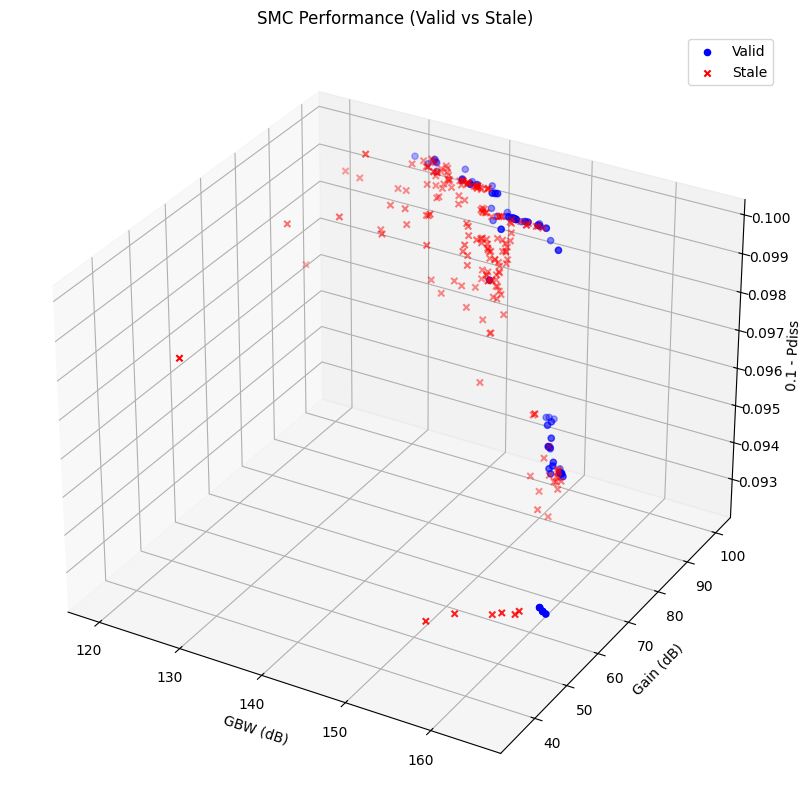

In [11]:
# Plot
plot_database_csv_withSTALE(csv_path, ckt_name)
# Can be compared before and after

In [12]:
# Read the data
current_samples_all, _ = read_para_perf_from_csv(csv_path, contain_stale=True)
current_samples_pareto, _ = read_para_perf_from_csv(csv_path, contain_stale=False)

print("There are ", current_samples_all.shape[0], " samples in the database")
print("There are ", current_samples_pareto.shape[0], " Pareto samples in the database")
print("--"*20)
print("Before optimization, the number of samples in the database is: ", initial_samples_all.shape[0])
print("Before optimization, the number of Pareto samples in the database is: ", initial_samples_pareto.shape[0])

There are  286  samples in the database
There are  105  Pareto samples in the database
----------------------------------------
Before optimization, the number of samples in the database is:  194
Before optimization, the number of Pareto samples in the database is:  54


# Other Circuits

**50-50-50-50-10: TuRBO uses 10 points per batch; NSGA-II uses 50 initial points, still 2,500 simulations**

Other circuits also use 50 initial points but only 10 iterations, for 500 simulations total.

In [24]:
ckt_lists = ['NMCNR', 'DFCFC1', 'NGCC', 'TCFC', 'AZC', 'IAC']

for ckt_name in ckt_lists:
    print(f'\n\n\n\033[32m{"-"*20} {ckt_name} {"-"*20}\033[0m')
    
    # Interface
    # Use CSMC018
    technique_path = './circuits/design_space.json'
    scs_mdl_path = './circuits'
    run_path = './runs'
    database_path = './circuit_database'

    # Check if there is a directory of scs and mdl files for the circuit
    if not os.path.exists(scs_mdl_path+'/'+ckt_name):
        print(f'\033[31mPlease add netlist and testbench files (in the format of scs and mdl) for the circuit [{ckt_name}] before running the Benchmark\033[0m')
        
    scs_mdl_paths = [
        {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.mdl', 'name': 'da'},
        {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.mdl', 'name': 'tran'},
        ]

    ckt_database_path = database_path + '/' + ckt_name
    
    if not os.path.exists(database_path+'/'+ckt_name):
        os.system(f'mkdir {database_path}/{ckt_name}')
        
        # raw/ stores original netlists and test files
        os.system(f'mkdir {database_path}/{ckt_name}/raw')
        os.system(f'cp {scs_mdl_path}/{ckt_name}/* {database_path}/{ckt_name}/raw')
        
        # result.csv stores high-performing metrics and parameter pairs discovered during exploration
        os.system(f'touch {database_path}/{ckt_name}/result.csv')
        # The CSV header is GBW, Gain, Pdiss, time, performance weight, solution vector, solution path
        with open(f'{database_path}/{ckt_name}/result.csv', 'w') as f:
            f.write('GBW, Gain, Pdiss, Fitness, time, performance weight, solution vector, solution path\n')
        
        # result_folder stores complete netlists and simulation results corresponding to the performance metrics
        os.system(f'mkdir {database_path}/{ckt_name}/result_folder')
        
    # Read database parameters
    csv_path = ckt_database_path + '/' + 'result.csv'
    # csv read
    ckt_database_csv = pd.read_csv(csv_path)
    # Strip whitespace from column names
    ckt_database_csv.columns = ckt_database_csv.columns.str.strip()

    # info head groupby
    print(ckt_database_csv.info())
    print("--"*20)

    # print(ckt_database_csv.head())
    # print("--"*20)

    # Print the distribution of performance weight, grouped by value
    print(ckt_database_csv['performance weight'].value_counts())

    # Print the counts of STALE and non-STALE `solution path` entries
    print("STALE Cound: ",ckt_database_csv[ckt_database_csv['solution path'] == 'STALE'].shape[0])
    print("VALID Count: ", ckt_database_csv[ckt_database_csv['solution path'] != 'STALE'].shape[0])
    
    # print(read_para_perf_from_csv(csv_path, contain_stale=True))
    initial_samples_all, _ = read_para_perf_from_csv(csv_path, contain_stale=True)
    initial_samples_pareto, _ = read_para_perf_from_csv(csv_path, contain_stale=False)

    print("All param shape: ", initial_samples_all.shape)
    print("Pareto param shape: ", initial_samples_pareto.shape)
    
    # Parameter configuration
    circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)
    # Optimization-parameter dimension
    var_dim = len(circuit.variables)
    # Optimization-parameter bounds
    var_lb = np.array(circuit.lb)
    var_ub = np.array(circuit.ub)
    # Objective dimension
    obj_dim = 3 # GBW, Gain, Pdiss（Multi-objective optimization directly uses circuit performance as the objectives）
    
    # Simulator
    from paradigm.netlist_utils import C2P_Simulator
    circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)
    C2P_Sim = C2P_Simulator(scs_mdl_paths, run_path, ckt_name, circuit.params, circuit.wsub, database_path, ["NSGA-II"], Save2Database_flag=True)    # Each simulation result may be saved to the database according to whether it is Pareto-optimal
    # C2P_Sim accepts a PyTorch tensor z with shape (n_samples, n_var) and returns performance metrics with shape (n_samples, n_obj)

    # Define the optimization problem

    target_problem = CircuitProblem(
        n_var=var_dim,
        n_obj=obj_dim,
        lb=var_lb,
        ub=var_ub,
        simulator=inv_simulator_np  # Ensure that the problem matches the optimization algorithm: this is a minimize algorithm, so every Simulator output dimension must be minimized
        # NOTE: If the problem and algorithm directions do not match (for example, some Simulator objectives are maximized and others minimized) but minimize is still used
        # the algorithm may fail to converge; pymoo may compute an invalid negative progress percentage and raise an error
        
    )

    # Configure the NSGA2 algorithm
    initial_samples_count = 50
    initial_samples = initial_samples_all.copy()

    if initial_samples.shape[0] > initial_samples_count:
        # Prefer Pareto-optimal samples
        if initial_samples_pareto.shape[0] > initial_samples_count:
            # If the number of Pareto-optimal samples exceeds the initial population size
            # Sample randomly without replacement
            initial_samples = initial_samples_pareto[np.random.choice(initial_samples_pareto.shape[0], initial_samples_count, replace=False)]
        else:
            # If the number of Pareto-optimal samples is smaller than the initial population size
            # Use the best samples plus the remaining samples drawn randomly without replacement
            initial_samples = np.vstack((initial_samples_pareto, initial_samples_all[np.random.choice(initial_samples_all.shape[0], initial_samples_count - initial_samples_pareto.shape[0], replace=False)]))
    else:
        # If there are too few initial points, fill the population with random samples automatically
        to_generate_count = initial_samples_count - initial_samples.shape[0]
        generated_samples = np.random.uniform(low=var_lb, high=var_ub, size=(to_generate_count, var_dim))
        initial_samples = np.vstack((initial_samples, generated_samples))

    print("Initial samples shape: ", initial_samples.shape)
    print("Initial samples size: ", initial_samples_count)
    algorithm = NSGA2(
        pop_size=initial_samples_count,
        sampling=initial_samples  # Set the initial population
    )

    # Define the stopping condition, such as a fixed number of generations
    termination = get_termination("n_gen", 50)

    # Run the optimization
    res = minimize(
        target_problem,
        algorithm,
        termination,
        seed=1,
        verbose=True
    )

    # Save another result after optimization
    time_stamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    save_file_path = f'{database_path}/{ckt_name}/result_{time_stamp}_allweights_nsga2.csv'
    os.system(f'cp {database_path}/{ckt_name}/result.csv {save_file_path}')
    print(f'\033[32mSave nsga2 result to {save_file_path}\033[0m')

    # Plot
    draw_path = f'{database_path}/{ckt_name}/result.csv'
    draw_pareto_NSGA2(draw_path,ckt_name)
    
    # Read the data
    current_samples_all, _ = read_para_perf_from_csv(csv_path, contain_stale=True)
    current_samples_pareto, _ = read_para_perf_from_csv(csv_path, contain_stale=False)

    print("There are ", current_samples_all.shape[0], " samples in the database")
    print("There are ", current_samples_pareto.shape[0], " Pareto samples in the database")
    print("--"*20)
    print("Before optimization, the number of samples in the database is: ", initial_samples_all.shape[0])
    print("Before optimization, the number of Pareto samples in the database is: ", initial_samples_pareto.shape[0])




-------------------- NMCNR --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GBW                 267 non-null    float64
 1   Gain                267 non-null    float64
 2   Pdiss               267 non-null    float64
 3   Fitness             267 non-null    object 
 4   time                267 non-null    object 
 5   performance weight  267 non-null    object 
 6   solution vector     267 non-null    object 
 7   solution path       267 non-null    object 
dtypes: float64(3), object(5)
memory usage: 16.8+ KB
None
----------------------------------------
performance weight
[1, 1, 1]      117
['NSGA-II']     85
[1, 0, -1]      47
[0, -1, 1]      12
[-1, 1, 0]       6
Name: count, dtype: int64
STALE Cound:  206
VALID Count:  61
All param shape:  (267, 27)
Pareto param shape:  (61, 27)
Initial samples shape: 

AssertionError: Invalid progress was set by the TerminationCriterion.